In [61]:
import sys

sys.path.append("..")
from qiskit.quantum_info import SparsePauliOp
from qiskit import QuantumCircuit
from qiskit.circuit.library import PauliEvolutionGate
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from numbers import Number
from qiskit.synthesis import LieTrotter
import numpy as np
import scipy as scipy
import matplotlib.pyplot as plt

### State preparation with 1 ancilla and 2 excitations on a total of 35 qubits

In [62]:
def prep_psi_0(qc: QuantumCircuit):
    qc.cx(34, 4)
    qc.cx(34, 21)
    return qc


def prep_psi_0_by_0(qc: QuantumCircuit):
    qc.cx(34, 4, ctrl_state="0")
    qc.cx(34, 21, ctrl_state="0")
    return qc

### Test if state prep works as expected

In [63]:
from qiskit_aer import StatevectorSimulator
from qiskit_aer.primitives import SamplerV2

# sv = StatevectorSimulator()
sampler = SamplerV2(options={"backend_options": {"method": "matrix_product_state"}})
qc = QuantumCircuit(35)
qc.h(34)
qc = prep_psi_0(qc)
qc.measure_all()

job = sampler.run([qc])
res = job.result()

res[0].data.meas.get_counts()

{'10000000000001000000000000000010000': 519,
 '00000000000000000000000000000000000': 505}

In [64]:
qc = QuantumCircuit(35)
qc.h(34)
qc = prep_psi_0(qc)
qc = prep_psi_0_by_0(qc)
qc.measure_all()
job = sampler.run([qc])
res = job.result()

res[0].data.meas.get_counts()

{'10000000000001000000000000000010000': 473,
 '00000000000001000000000000000010000': 551}

## Hardware experiments

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService
 
QiskitRuntimeService.save_account(
  token=token,
  channel="ibm_cloud", # `channel` distinguishes between different account types.
  instance="crn:v1:bluemix:public:quantum-computing:us-east:a/6c63dae5281147f1a0449b36e0aaba3a:068b8d3f-2983-4154-822a-f19a296847ec::", # Copy the instance CRN from the Instance section on the dashboard.
)

service = QiskitRuntimeService()
backend = service.backend("ibm_torino")

In [ ]:
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService(instance="ibm-q-qida/ibm/main", channel="ibm_quantum")
backend = service.backend("ibm_torino")

t_steps = 8
num_qubits = 34
circuits = np.ndarray([t_steps, t_steps], dtype=QuantumCircuit)
H_tilde = np.zeros([t_steps, t_steps], dtype=complex)
S_tilde = np.zeros([t_steps, t_steps], dtype=complex)
delta_t = np.pi / 40
synth = LieTrotter(reps=1)

qubit_subset = (
    list(range(42, 48))
    + [35]
    + list(range(25, 30))
    + [36, 48, 49, 50, 54]
    + list(range(61, 66))
    + list(range(66, 70))
    + [56, 73, 82, 83, 84, 85, 86, 74]
)
# remap = {q: i for q, i in zip(qubit_subset, range(len(qubit_subset)))}
# rev_map = {val: key for key, val in remap.items()}


cm = backend.coupling_map
reduced_map = cm.reduce(qubit_subset)
edge_list = {(a, b) if a < b else (b, a) for a, b in list(reduced_map.get_edges())}
# ent_dec = [(rev_map[i], rev_map[j]) for i, j in edge_list]


def Heisenberg(J, n, ent_map):
    if isinstance(J, Number):
        J = np.ones(len(ent_map)) * J
    else:
        assert len(J) == len(ent_map)
    String = "I" * n
    H = SparsePauliOp("I" * n, 0)
    for j, c in zip(J, ent_map):
        c = np.sort(c)
        XX = String[: c[0]] + "X" + String[c[0] + 1 : c[1]] + "X" + String[c[1] + 1 :]
        H += SparsePauliOp(XX, j)
        YY = String[: c[0]] + "Y" + String[c[0] + 1 : c[1]] + "Y" + String[c[1] + 1 :]
        H += SparsePauliOp(YY, j)
        ZZ = String[: c[0]] + "Z" + String[c[0] + 1 : c[1]] + "Z" + String[c[1] + 1 :]
        H += SparsePauliOp(ZZ, j)
    return H.chop()


H = Heisenberg(1, num_qubits, edge_list)

# Generate approximate time evolution, rather than using PauliEvolutionGate
Rxyz_circ = QuantumCircuit(2)
Rxyz_circ.rxx(2 * delta_t, 0, 1)
Rxyz_circ.ryy(2 * delta_t, 0, 1)
Rxyz_circ.rzz(2 * delta_t, 0, 1)
Rxyz_instr = Rxyz_circ.to_instruction(label="RXX+YY+ZZ")
qc_temp = QuantumCircuit(num_qubits)
for edge in edge_list:
    qc_temp.append(Rxyz_instr, edge)
time_evol = QuantumCircuit(num_qubits).compose(qc_temp)

# time_evol=PauliEvolutionGate(H,time=delta_t,synthesis=synth)
real_obs_H = SparsePauliOp("X", 1) ^ H
imag_obs_H = SparsePauliOp("Y", 1) ^ H
real_obs_S = SparsePauliOp("X", 1) ^ SparsePauliOp("I" * 34, 1)
imag_obs_S = SparsePauliOp("Y", 1) ^ SparsePauliOp("I" * 34, 1)


for j in range(t_steps):
    for i in range(j + 1):
        m = i
        n = j - i
        qc = QuantumCircuit(35)
        qc.h(34)
        qc = prep_psi_0(qc)
        for _ in range(n):
            qc.append(time_evol, range(34))
        qc = prep_psi_0_by_0(qc)
        for _ in range(m):
            qc.append(time_evol, range(34))
        circuits[i][j] = qc.copy()

init_layout = qubit_subset + [55]  # ancilla at qubit 55 on torino
pm = generate_preset_pass_manager(
    backend=backend, optimization_level=3, initial_layout=init_layout
)

circs = []
for i in range(t_steps):
    circs.append([])
    for j in range(t_steps):
        if circuits[i][j] is not None:
            circs[i].append(circuits[i][j])
        else:
            circs[i].append(circuits[j][i])

circs = [pm.run(circ) for circ in circs]

print(
    f"Max circuit depth:{max([circs[i][j].depth(lambda x: len(x.qubits)==2) for i in range(t_steps) for j in range(t_steps)])}"
)

Max circuit depth:73


# Circuit execution

## Run as individual jobs to allow more shots

In [91]:
from qiskit_ibm_runtime import EstimatorV2, Batch, EstimatorOptions

estimator = EstimatorV2(mode=backend)
estimator.options.default_shots = 800000  # Try going upto 1000000
estimator.options.resilience_level = 2
estimator.options.dynamical_decoupling.enable = True
estimator.options.dynamical_decoupling.sequence_type = "XY4"
estimator.options.resilience.zne.noise_factors = (1, 1.3, 1.6)  # use fractional folding
estimator.options.resilience.zne.extrapolator = (
    "linear"  # exponential fit showed high std's, use this instead.
)
# estimator.options.experimental = {"execution_path": "gen3-turbo"}

est_jobs = []
for i in range(t_steps):
    for j in range(t_steps):
        if circuits[i][j] is not None:
            circ = circs[i][j]
        else:
            circ = circs[j][i]
        est_jobs.append(
            estimator.run(
                [
                    (
                        circ,
                        [
                            real_obs_H.apply_layout(circ.layout),
                            imag_obs_H.apply_layout(circ.layout),
                            real_obs_S.apply_layout(circ.layout),
                            imag_obs_S.apply_layout(circ.layout),
                        ],
                    )
                ]
            )
        )

In [93]:
job_results = [job.result() for job in est_jobs]
print([job for job in est_jobs if job.errored()])  # check if any of the jobs errored.

[]


In [94]:
H_tilde = np.zeros([t_steps, t_steps], dtype=complex)
S_tilde = np.zeros([t_steps, t_steps], dtype=complex)
idx = 0
for i in range(t_steps):
    for j in range(t_steps):
        if circuits[i][j] is not None:
            H_tilde[i, j] = (
                job_results[idx][0].data.evs[0] + 1j * job_results[idx][0].data.evs[1]
            )
            S_tilde[i, j] = (
                job_results[idx][0].data.evs[2] + 1j * job_results[idx][0].data.evs[3]
            )
        else:
            H_tilde[i, j] = np.conj(H_tilde[j, i])
            S_tilde[i, j] = np.conj(S_tilde[j, i])
        idx += 1

In [96]:
from sympy import Matrix

Matrix(S_tilde)

Matrix([
[   0.959575828823403 - 0.00857742061309832*I,    0.853644935323086 + 0.418176280511675*I,     0.322306270096692 + 0.53406134050212*I,  -0.0604873934886156 + 0.527410358098642*I, -0.149658109243103 + 0.232048269271491*I,  -0.112897581585932 + 0.0838076172071938*I, -0.0641644224364905 + 0.0256418911729134*I, -0.0145032378661772 - 0.000942306597573612*I],
[     0.853644935323086 - 0.418176280511675*I,    1.02470389252582 - 0.0417487614520974*I,     0.80975080872664 + 0.538049079234427*I,    0.248895925146419 + 0.721160664558261*I, 0.0114287671699229 + 0.586514652907093*I,    -0.176416485190081 + 0.27465530645776*I,  -0.131920433355231 + 0.0893072341366739*I,   -0.0626920226119782 + 0.0090969723532626*I],
[      0.322306270096692 - 0.53406134050212*I,     0.80975080872664 - 0.538049079234427*I,   1.05075628272806 + 0.00340987329899902*I,    0.818956670308778 + 0.416913481429479*I,  0.238775000195693 + 0.611516013778219*I, -0.00986057924252739 + 0.540606927700259*I,   -0.157005240

In [97]:
Matrix(H_tilde)

Matrix([
[   26.814284896499 - 0.265352296555781*I,    18.6785769981071 + 8.69132940707286*I,   7.21646854457641 + 8.61683138017184*I,  1.56586756707595 + 8.95790207563456*I, -0.372146007313353 + 3.80935237734334*I,  -0.472579441313158 + 2.08885924608904*I, -0.396913480737988 + 1.01822023613189*I, -0.114974692104677 + 0.390386914780405*I],
[   18.6785769981071 - 8.69132940707286*I,    25.7611186973126 - 1.27309880717613*I,     17.4834792691221 + 10.44377463844*I,  5.61565909972372 + 11.3561394551261*I,   2.69291255098648 + 7.47667364009326*I, -0.0260345473844147 + 4.30863422848747*I,  -0.65310493955123 + 1.75490842836544*I, -0.579642036234153 + 0.886440530792838*I],
[   7.21646854457641 - 8.61683138017184*I,      17.4834792691221 - 10.44377463844*I,  22.2312571856084 - 0.437184827517077*I,  15.2592186376797 + 7.03015639314767*I,   5.07758924771668 + 7.77065616584359*I,     2.3614604774124 + 6.22225712970981*I, -0.210220747753656 + 2.68298083999676*I,   -0.667239429035696 + 1.8975700554

In [573]:
def truncation(threshold, S):
    eigvals, eigvecs = np.linalg.eig(S)
    idx = eigvals.argsort()[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]
    D = len(eigvals)
    truncated_eigvals = []
    truncated_eigvecs = []
    # make truncated matrix whose rows are eigenvectors of S with eigval above threshold
    for i in range(D):
        if eigvals[i] >= threshold:
            truncated_eigvals.append(eigvals[i])
            truncated_eigvecs.append(eigvecs[i])
    truncated_eigvals = np.array(truncated_eigvals)
    truncated_eigvecs = np.array(truncated_eigvecs).T
    print(len(truncated_eigvals))
    return truncated_eigvecs


def E_vs_D(H_tilde, S_tilde, threshold_slope):
    GSEs = []
    ground_states = []
    for d in range(1, len(S_tilde)+1):
        epsilon = threshold_slope
        H_temp = H_tilde[0:d, 0:d]
        S_temp = S_tilde[0:d, 0:d]
        V_eps = truncation(epsilon, S_temp)
        # solve GEVP
        A = V_eps.conj().T @ H_temp @ V_eps
        B = V_eps.conj().T @ S_temp @ V_eps
        E, c = scipy.linalg.eig(a=A, b=B)
        idx = E.argsort()[::-1]
        eigvals = E[idx]
        eigvecs = c[:, idx]
        GSEs.append(eigvals[-1])
        ground_states.append(eigvecs[:, -1])
        print(min(eigvals))

    return GSEs, ground_states, V_eps

## Run on simulator for comparison

In [341]:
from qiskit_aer.noise import NoiseModel

nm = NoiseModel()
nm.from_backend(backend=backend)

<NoiseModel on ['sx', 'cz', 'reset', 'x', 'id', 'measure']>

In [585]:
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.primitives import StatevectorEstimator
from qiskit_aer.primitives import EstimatorV2

from qiskit_aer.noise import NoiseModel

backend = service.backend("ibm_torino")

t_steps = 8
n_qubits = 34  # number of data qubits
circuits = np.ndarray([t_steps, t_steps], dtype=QuantumCircuit)
H_tilde_sim = np.zeros([t_steps, t_steps], dtype=complex)
S_tilde_sim = np.zeros([t_steps, t_steps], dtype=complex)
delta_t = np.pi / 40
synth = LieTrotter(reps=1)
num_shots = 10**12

H = Heisenberg(1, n_qubits, edge_list)

# Rxyz_circ = QuantumCircuit(2)
# Rxyz_circ.rxx(2 * delta_t, 0, 1)
# Rxyz_circ.ryy(2 * delta_t, 0, 1)
# Rxyz_circ.rzz(2 * delta_t, 0, 1)
# Rxyz_instr = Rxyz_circ.to_instruction(label="RXX+YY+ZZ")
# qc_temp = QuantumCircuit(n_qubits)
# for edge in edge_list:
#     qc_temp.append(Rxyz_instr, edge)
# time_evol = QuantumCircuit(n_qubits).compose(qc_temp)


time_evol = PauliEvolutionGate(H, time=delta_t, synthesis=synth)

real_obs_H = SparsePauliOp("X", 1) ^ H
imag_obs_H = SparsePauliOp("Y", 1) ^ H
real_obs_S = SparsePauliOp("X", 1) ^ SparsePauliOp("I" * n_qubits, 1)
imag_obs_S = SparsePauliOp("Y", 1) ^ SparsePauliOp("I" * n_qubits, 1)


for j in range(t_steps):
    for i in range(j + 1):
        m = i
        n = j - i
        qc = QuantumCircuit(35)
        qc.h(34)
        qc = prep_psi_0(qc)
        for _ in range(n):
            qc.append(time_evol, range(34))
        qc = prep_psi_0_by_0(qc)
        for _ in range(m):
            qc.append(time_evol, range(34))
        circuits[i][j] = qc.copy().decompose(reps=4)

simulator = EstimatorV2(
    options={
        "backend_options": {"method": "matrix_product_state"},# , "noise_model": nm},
        "default_precision": 1 / np.sqrt(num_shots),
    }
)
for i in range(t_steps):
    for j in range(t_steps):
        if circuits[i][j] is not None:
            sim_job = simulator.run(
                [
                    (
                        circuits[i][j],
                        [real_obs_H, imag_obs_H, real_obs_S, imag_obs_S],
                    )
                ]
            )
            H_tilde_sim[i, j] = (
                sim_job.result()[0].data.evs[0] + 1j * sim_job.result()[0].data.evs[1]
            )
            S_tilde_sim[i, j] = (
                sim_job.result()[0].data.evs[2] + 1j * sim_job.result()[0].data.evs[3]
            )
        else:
            sim_job = simulator.run(
                [
                    (
                        circuits[j][i],
                        [real_obs_H, imag_obs_H, real_obs_S, imag_obs_S],
                    )
                ]
            )
            H_tilde_sim[i, j] = (
                sim_job.result()[0].data.evs[0] - 1j * sim_job.result()[0].data.evs[1]
            )
            S_tilde_sim[i, j] = (
                sim_job.result()[0].data.evs[2] - 1j * sim_job.result()[0].data.evs[3]
            )

In [586]:
Matrix(H_tilde_sim)

Matrix([
[27.9999996424383 - 1.45961005532277e-6*I,     22.2941777422065 + 14.725429184642*I,    9.20204756628023 + 21.1987189995306*I,  -2.74436086250085 + 17.7457593311466*I,   -7.82583681281467 + 9.50792397523014*I,   -6.64529503614745 + 2.80517885753008*I, -3.37741959344975 + 0.0855521842677546*I, -1.05157464581297 - 0.0488224767675775*I],
[   22.2941767375058 - 14.7254325925445*I, 28.0465197573089 + 1.64931831590347e-6*I,    22.3222576145327 + 14.7542616581185*I,   9.20015508273243 + 21.2285735653946*I,   -2.75978510855391 + 17.7556313767206*I,    -7.83292996902613 + 9.5019631864929*I,   -6.64001680743321 + 2.80044635380352*I, -3.37090514971812 + 0.0891150849038467*I],
[    9.2020474517692 - 21.1987198224674*I,    22.3222588068657 - 14.7542604364155*I, 28.0804550849199 + 9.10822145167931e-7*I,   22.3377641680603 + 14.7720087618488*I,    9.19607528582518 + 21.2400167194701*I,   -2.76493597850905 + 17.7511669251586*I,   -7.82583087755845 + 9.49324144941535*I,   -6.62651779118284 + 2

In [587]:
Matrix(S_tilde_sim)

Matrix([
[ 0.999999515637857 + 9.53583834994952e-7*I,     0.769906909394308 + 0.55936930977384*I,   0.255817706468956 + 0.776535853945119*I,    -0.183386019602207 + 0.6000712439906*I,  -0.328056414956934 + 0.263931843752839*I, -0.235343246989037 + 0.0274040349753893*I, -0.0952233762815995 - 0.0371359853388698*I, -0.0195578251989127 - 0.0161433596115558*I],
[   0.769904923118028 - 0.559369936866917*I,   1.00000087873969 - 2.47451043549408e-7*I,   0.769905386355206 + 0.559369142991868*I,    0.25581664660103 + 0.776535136148091*I,  -0.183384822469139 + 0.600070171943425*I,   -0.32805620053215 + 0.263931648661544*I,  -0.235343169183819 + 0.0274052883092795*I,  -0.0952261378789662 - 0.037135609781511*I],
[   0.255818060184225 - 0.776536805657819*I,     0.769904828301625 - 0.55936834047136*I, 0.999999654280614 - 3.21214867716466e-7*I,   0.769905674578974 + 0.559370969459661*I,   0.255818567741307 + 0.776535120035331*I,  -0.183385033095601 + 0.600070813931697*I,    -0.328056197397605 + 0.2639

1
(28.00001320455782-2.815998366646436e-05j)
2
(23.902512147239857-0.00024211740615741868j)
3
(21.55552365533844-0.0003983410181703525j)
3
(21.661358485581864+0.001254494397315892j)
4
(20.49519479828765+0.014220893321167273j)
4
(20.47121614107471+0.0023417189182383855j)
5
(1.6998498572795913+15.315980281337989j)
5
(20.00732140010541+0.05841017047027632j)
1
(27.94413270210361-0.026744855310778724j)
2
(23.93308633482727-0.12234866748708068j)
2
(21.36697028742094-0.21064780547978668j)
3
(18.445609457845997-0.350833273817422j)
4
(-67.57488691515016-49.24999968535908j)
5
(-7.356175789657901+1.5468269541917505j)
5
(-17.310868125740225-9.233384733686934j)
6
(10.101085756073385-48.48927348602218j)


/Users/ibrahimshehzad/uds/lib/python3.10/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/ibrahimshehzad/uds/lib/python3.10/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0, 0.5, 'Ground state energy')

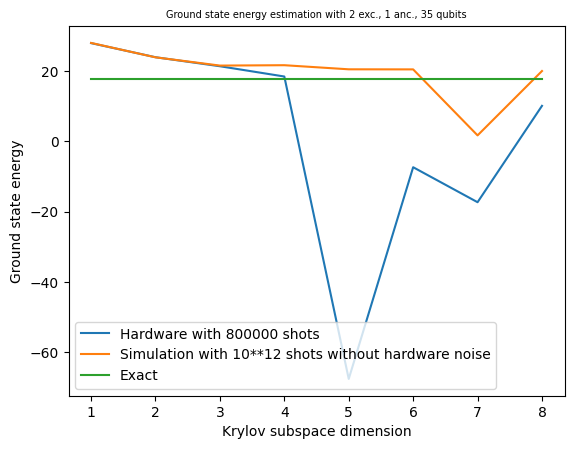

In [588]:
GSEs_sim, gstates_sim, _ = E_vs_D(H_tilde_sim, S_tilde_sim,1e-4)
GSEs, _, _ = E_vs_D(H_tilde, S_tilde, 1 /50)
plt.plot(list(range(1, len(S_tilde_sim) + 1)),
         GSEs, label="Hardware with 800000 shots"
)  # Ground-state energies
plt.plot(
    list(range(1, len(S_tilde_sim) + 1)),
         GSEs_sim,
    label=f"Simulation with 10**12 shots without hardware noise",
)
plt.plot(
    list(range(1, len(S_tilde_sim)+1)),
    17.81817798453781 * np.ones(t_steps),
    label="Exact",
)
plt.title("Ground state energy estimation with 2 exc., 1 anc., 35 qubits", fontsize=7)
plt.legend(loc="lower left")
plt.xlabel("Krylov subspace dimension")
plt.ylabel("Ground state energy")

In [471]:
for j in range(t_steps):
    for i in range(j + 1):
        m = i
        n = j - i
        qc = QuantumCircuit(35)
        qc.h(34)
        qc = prep_psi_0(qc)
        for _ in range(n):
            qc.append(time_evol, range(34))
        qc = prep_psi_0_by_0(qc)
        for _ in range(m):
            qc.append(time_evol, range(34))
        circuits[i][j] = qc.copy().decompose(reps=4)

In [482]:
from qiskit_aer.primitives import SamplerV2
simulator = SamplerV2(default_shots=800000,
    options={
        "backend_options": {"method": "matrix_product_state"},
    }
)
for i in range(t_steps):
    for j in range(t_steps):    
        if circuits[i][j] is not None:
            circuits[i][j].measure_all()
            s_job = simulator.run([circuits[i][j]])
        else:
            circuits[j][i].measure_all()
            s_job = simulator.run([circuits[j][i]])

        print([x.count('1') for x in list(s_job.result()[0].data.meas.get_counts().keys()) if (x[1:].count('1') != 2)])

[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]


## Exact diagonalisation for comparison

In [547]:
# Method from Krylov tutorial
import itertools as it
import scipy as sp
from qiskit.quantum_info import Pauli


def n_particle_gs(H_op, n_qubits, n_exc):
    """
    Find the ground state of the n particle(excitation) sector
    """
    H_x = []
    for p, coeff in H_op.to_list():
        H_x.append(set([i for i, v in enumerate(Pauli(p).x) if v]))

    H_z = []
    for p, coeff in H_op.to_list():
        H_z.append(set([i for i, v in enumerate(Pauli(p).z) if v]))

    H_c = H_op.coeffs

    n_exc = n_exc
    sub_dimn = int(sp.special.comb(n_qubits, n_exc))
    print("n_exc", n_exc, ", subspace dimension", sub_dimn)

    n_particle_H = np.zeros((sub_dimn, sub_dimn), dtype=complex)

    sparse_vecs = [
        set(vec) for vec in it.combinations(range(n_qubits), r=n_exc)
    ]  # list all of the possible sets of n_exc indices of 1s in n_exc-particle states
    for i, i_set in enumerate(sparse_vecs):
        for j, j_set in enumerate(sparse_vecs):
            if len(i_set.symmetric_difference(j_set)) <= 2:

                for p_x, p_z, coeff in zip(H_x, H_z, H_c):

                    if i_set.symmetric_difference(j_set) == p_x:
                        sgn = ((-1j) ** len(p_x.intersection(p_z))) * (
                            (-1) ** len(i_set.intersection(p_z))
                        )
                    else:
                        sgn = 0

                    n_particle_H[i, j] += sgn * coeff

    eige, eigv = np.linalg.eigh(n_particle_H)
    gs_en = eige[0]  # min(eige)
    gs_vec = eigv[:, 0]
    print("n_exc particle ground state energy: ", gs_en)
    return gs_en, gs_vec, n_particle_H


n_qubits = 34
edge_list = edge_list
H = Heisenberg(1, n_qubits, edge_list)
en, state, subspace_h = n_particle_gs(H, n_qubits, 2)
# print(np.linalg.norm(subspace_h,ord=2))

n_exc 2 , subspace dimension 561
n_exc particle ground state energy:  17.81817798453781
